In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow import keras
from pathlib import Path

2026-01-15 13:08:00.132851: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-15 13:08:00.535589: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 13:08:03.415576: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.



UMBRAL: 0.28

True Negatives (TN):    12863 - Benignos correctos
False Positives (FP):    2204 - Benignos mal clasificados ⚠️
False Negatives (FN):     247 - Malignos perdidos ⚠️⚠️
True Positives (TP):     1811 - Malignos detectados

Total predicciones:    17125

Accuracy:  0.857
Precision: 0.451 (de los que digo 'maligno', cuántos lo son)
Recall:    0.880 (de los malignos reales, cuántos detecto)
F1-Score:  0.596



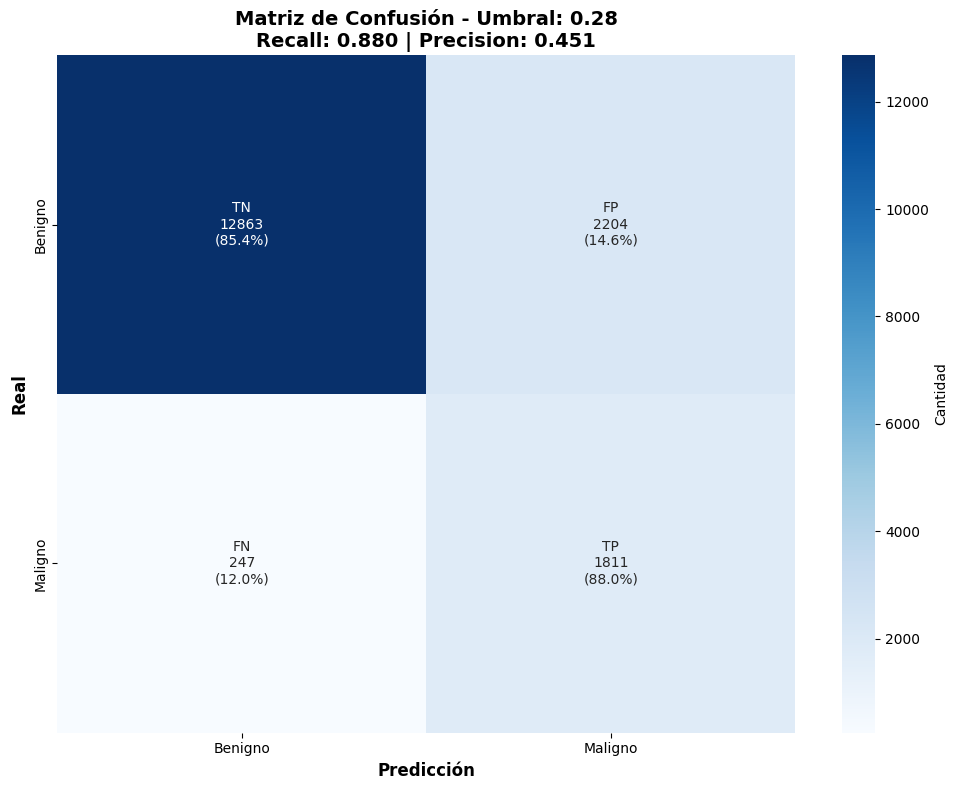

In [2]:
# ============================================
# CONFIGURACIÓN
# ============================================
UMBRAL = 0.28  # <-- valor para ajustar el umbral

# ============================================
# CARGAR DATOS
# ============================================
outputs_dir = Path('../outputs/comparision_resnet')
latest_run = sorted(outputs_dir.glob('resnet50_20260110_001917-normal'))[-1]
scores_path = latest_run / 'prediction_scores_test.csv'

df = pd.read_csv(scores_path)

# Ajusta según tu CSV:
scores = df['predicted_score'].values.reshape(-1, 1)  # Columna de scores
labels = df['true_label'].values  # Columna de etiquetas reales

# ============================================
# PREDICCIONES CON UMBRAL
# ============================================
preds = (scores[:,0] >= UMBRAL).astype(int)

# ============================================
# MATRIZ DE CONFUSIÓN
# ============================================
cm = confusion_matrix(labels, preds)

# ============================================
# EXTRAER TN, FP, FN, TP
# ============================================
TN = cm[0, 0]  # True Negatives (Benign correctamente clasificado)
FP = cm[0, 1]  # False Positives (Benign clasificado como Malignant)
FN = cm[1, 0]  # False Negatives (Malignant clasificado como Benign)
TP = cm[1, 1]  # True Positives (Malignant correctamente clasificado)

# ============================================
# IMPRIMIR VALORES
# ============================================
print(f"\n{'='*50}")
print(f"UMBRAL: {UMBRAL}")
print(f"{'='*50}")
print(f"\nTrue Negatives (TN):   {TN:>6} - Benignos correctos")
print(f"False Positives (FP):  {FP:>6} - Benignos mal clasificados ⚠️")
print(f"False Negatives (FN):  {FN:>6} - Malignos perdidos ⚠️⚠️")
print(f"True Positives (TP):   {TP:>6} - Malignos detectados")
print(f"\n{'='*50}")
print(f"Total predicciones:    {TN + FP + FN + TP}")
print(f"{'='*50}\n")

# Calcular métricas manualmente
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f} (de los que digo 'maligno', cuántos lo son)")
print(f"Recall:    {recall:.3f} (de los malignos reales, cuántos detecto)")
print(f"F1-Score:  {f1:.3f}\n")

# ============================================
# GRAFICAR CON ANOTACIONES
# ============================================
plt.figure(figsize=(10, 8))

# Crear anotaciones personalizadas
annot_labels = np.array([
    [f'TN\n{TN}\n({cm[0,0]/cm[0].sum()*100:.1f}%)', 
     f'FP\n{FP}\n({cm[0,1]/cm[0].sum()*100:.1f}%)'],
    [f'FN\n{FN}\n({cm[1,0]/cm[1].sum()*100:.1f}%)', 
     f'TP\n{TP}\n({cm[1,1]/cm[1].sum()*100:.1f}%)']
])

sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'],
            cbar_kws={'label': 'Cantidad'})
plt.xlabel('Predicción', fontsize=12, fontweight='bold')
plt.ylabel('Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusión - Umbral: {UMBRAL}\nRecall: {recall:.3f} | Precision: {precision:.3f}', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()